# Solar CARMA order and ACF-based initialisation

This notebook is the solar analogue of `germany/germany23+24+25/02order.ipynb`.

The input series is not the raw solar capacity factor. It is the clear-sky-normalised,
latent, deseasonalised solar component

\[
X_t^Q = Y_t^Q - \Lambda_t^Q,
\]

obtained from the existing `solar_clearsky` calibration. The goal here is only to
build an ACF-based CARMA initialisation. The exact QMLE/Kalman optimisation is done
in `03mle_solar.ipynb`.

The default topology mirrors the German spot-price notebook: three real AR roots,
one fixed 24h complex-conjugate AR pair, and CARMA(5,4) after spectral factorisation.
The real and oscillatory half-lives are optimised inside explicit manual bounds.


In [1]:
%matplotlib inline

from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import least_squares
from scipy.linalg import expm, solve_continuous_lyapunov

plt.rcParams.update({
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

CWD = Path.cwd().resolve()
if (CWD / "solar" / "Intensity_Model_solar" / "intensity_calibration_solar.py").exists():
    REPO = CWD
    CODE = CWD / "solar" / "Intensity_Model_solar"
elif (CWD / "intensity_calibration_solar.py").exists():
    CODE = CWD
    REPO = CWD.parents[1]
else:
    raise FileNotFoundError("Run this notebook from the repo root or from solar/Intensity_Model_solar/.")

if str(CODE) not in sys.path:
    sys.path.insert(0, str(CODE))

from intensity_calibration_solar import run_intensity_model_calibration_solar

DATA = CODE / "data" / "carma"
OUT = DATA
FIG = CODE / "figures" / "carma"
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)


def first_existing(candidates, label):
    for path in candidates:
        p = Path(path)
        if p.exists():
            return p
    raise FileNotFoundError(f"Could not find {label}. Checked: " + ", ".join(str(Path(p)) for p in candidates))


spot_path = first_existing([
    REPO / "Vb-Academy PPAs Application" / "DayAheadPrices_2021_2025.csv",
    REPO / "DayAheadPrices_2021_2025.csv",
    REPO / "wind" / "Gabriel" / "DayAheadPrices_2021_2025.csv",
], "German day-ahead price CSV")

solar_path = first_existing([
    REPO / "enwex_GER_solar_v25_combined.csv",
    REPO / "wind" / "Gabriel" / "enwex_GER_solar_v25_combined.csv",
], "German solar capacity-factor CSV")

workspace = run_intensity_model_calibration_solar(
    spot_path=str(spot_path),
    solar_path=str(solar_path),
)

solar_variant = workspace.solar_variants["solar_clearsky"]
solar_fit = solar_variant.seasonality
transform = solar_fit.transform_params
if transform is None:
    raise RuntimeError("solar_clearsky seasonality has no transform parameters.")

solar_panel = pd.DataFrame({
    "solar_cf": solar_fit.physical_series,
    "solar_clear_sky": solar_fit.clear_sky_proxy,
    "solar_risk_driver": solar_fit.risk_driver,
    "solar_xprime": solar_fit.normalized_driver,
    "solar_latent_Y": solar_fit.series,
    "solar_latent_seasonality": solar_fit.fitted,
    "solar_XtQ": solar_fit.residual,
}).dropna()

panel_path = OUT / "solar_latent_panel.csv"
solar_panel.to_csv(panel_path)

metadata = {
    "source": "solar/Intensity_Model_solar/02order_solar.ipynb",
    "spot_path": str(spot_path),
    "solar_path": str(solar_path),
    "series": "solar_XtQ = solar_latent_Y - solar_latent_seasonality",
    "transform": {
        "alpha": float(transform.alpha),
        "beta": float(transform.beta),
        "epsilon": float(transform.epsilon),
        "clear_sky_floor": float(transform.clear_sky_floor),
        "clear_sky_quantile": float(transform.clear_sky_quantile),
        "clear_sky_smoothing_days": int(transform.clear_sky_smoothing_days),
    },
}
metadata_path = OUT / "solar_latent_metadata.json"
metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

pr = solar_panel["solar_XtQ"].to_numpy(float)
pr = pr[np.isfinite(pr)]
pr = pr - pr.mean()
N = len(pr)
v0 = float(pr @ pr / N)


def acf(k):
    k = int(k)
    return 1.0 if k == 0 else float(pr[:-k] @ pr[k:] / ((N - k) * v0))


def softmax(z):
    z = np.asarray(z, dtype=float)
    z = z - z.max()
    e = np.exp(z)
    return e / e.sum()


print(f"{N:,} hourly solar latent residuals XtQ")
print(f"variance target v0 = {v0:.6e}")
print(f"panel saved: {panel_path}")
print(f"metadata saved: {metadata_path}")


C:\Users\gabri\Documents\quant-projects\FR_carma_quanto\solar\Intensity_Model_solar\intensity_ar_solar.py:41: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(A, dtype=float)
C:\Users\gabri\Documents\quant-projects\FR_carma_quanto\solar\Intensity_Model_solar\intensity_ar_solar.py:41: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(A, dtype=float)


40,627 hourly solar latent residuals XtQ
variance target v0 = 7.028301e+00
panel saved: C:\Users\gabri\Documents\quant-projects\FR_carma_quanto\solar\Intensity_Model_solar\data\carma\solar_latent_panel.csv
metadata saved: C:\Users\gabri\Documents\quant-projects\FR_carma_quanto\solar\Intensity_Model_solar\data\carma\solar_latent_metadata.json


Manual half-life bounds used by the optimizer:


,lower_h,upper_h,lower_d,upper_d
component,,,,
real_fast,2.00,24.00,0.08,1.00
real_mid,5.00,168.00,0.21,7.00
real_slow,240.00,8760.00,10.00,365.00
osc_daily,12.00,4320.00,0.50,180.00


ACF calibration lags: 350
  short dense lags: 1..336 h
  long anchors h: [384, 432, 504, 600, 720, 960, 1200, 1440, 1800, 2160, 2520, 2880, 3600, 4320]
  plot window: 0..500 h
Best half-lives h [real fast, real mid, real slow, osc daily]: [  2.     79.631 240.    130.058]
Best half-lives d [real fast, real mid, real slow, osc daily]: [ 0.083  3.318 10.     5.419]
Optimizer status: 2 `ftol` termination condition is satisfied.


component,best_h,best_d,lower_h,upper_h,at_lower,at_upper
real_fast,2.00,0.08,2.00,24.00,True,False
real_mid,79.63,3.32,5.00,168.00,False,False
real_slow,240.00,10.00,240.00,8760.00,True,False
osc_daily,130.06,5.42,12.00,4320.00,False,False


component,kind,half_life_h,half_life_d,period_h,share
real_fast,real,2.00,0.08,inf,0.665
real_mid,real,79.63,3.32,inf,0.194
real_slow,real,240.00,10.00,inf,0.000
osc_daily,osc,130.06,5.42,24.0,0.141


RMSE=0.054525  WSSR=2.8167  (CARMA order 5)


lag_h,empirical,model,err
1,0.6421,0.7980,+0.1559
2,0.5260,0.6439,+0.1179
3,0.4624,0.5221,+0.0597
6,0.2516,0.2669,+0.0153
12,0.0889,0.0521,-0.0368
18,0.1890,0.1668,-0.0221
24,0.5569,0.2817,-0.2752
30,0.1378,0.1491,+0.0113
48,0.3870,0.2370,-0.1501
72,0.2891,0.1998,-0.0893


Long-lag anchors included in calibration.


lag_h,days,empirical,model,err
384,16.0,0.0841,0.0251,-0.0590
432,18.0,0.0445,0.0187,-0.0258
504,21.0,0.0121,0.0120,-0.0001
600,25.0,-0.0346,0.0068,+0.0415
720,30.0,-0.0373,0.0034,+0.0407
960,40.0,-0.0440,0.0009,+0.0449
1200,50.0,-0.0565,0.0002,+0.0567
1440,60.0,-0.0631,0.0001,+0.0632
1800,75.0,-0.0690,0.0000,+0.0690
2160,90.0,0.0144,0.0000,-0.0144


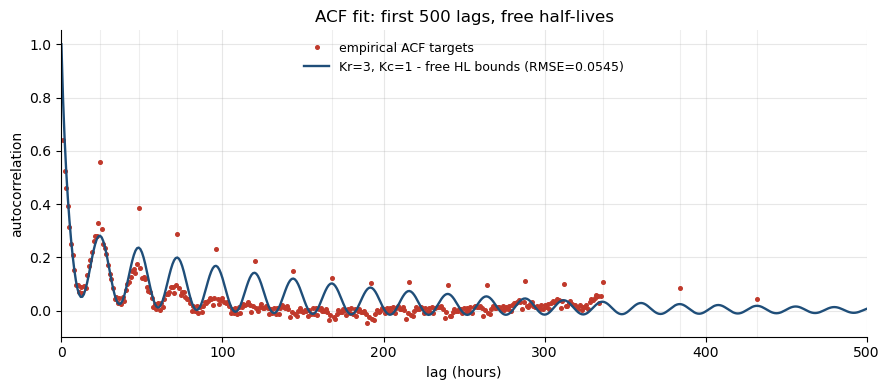

In [7]:
# ACF fit: Kr=3, Kc=1, fixed 24h period, free half-lives
Kr, Kc = 3, 1
m = Kr + Kc
n_hl = Kr + Kc
component_labels = np.array(["real_fast", "real_mid", "real_slow", "osc_daily"])
om_c_fixed = np.array([2 * np.pi / 24.0])

# Manual knobs. Edit these bounds before running the cell if the ACF fit
# pushes a mode to an implausible time scale.
ACF_PLOT_MAX_LAG_H = 500
HALF_LIFE_BOUNDS_H = pd.DataFrame({
    "component": component_labels,
    "lower_h": [2.0, 5.0, 10*24.0, 12.0],
    "upper_h": [24.0, 7 * 24.0, 365.0 * 24.0, 180.0 * 24.0],
}).set_index("component")

hl_lower_h = HALF_LIFE_BOUNDS_H.loc[component_labels, "lower_h"].to_numpy(float)
hl_upper_h = HALF_LIFE_BOUNDS_H.loc[component_labels, "upper_h"].to_numpy(float)
if np.any(hl_lower_h <= 0.0) or np.any(hl_upper_h <= hl_lower_h):
    raise ValueError("Half-life bounds must satisfy 0 < lower_h < upper_h for every component.")

bounds_display = HALF_LIFE_BOUNDS_H.copy()
bounds_display["lower_d"] = bounds_display["lower_h"] / 24.0
bounds_display["upper_d"] = bounds_display["upper_h"] / 24.0
print("Manual half-life bounds used by the optimizer:")
display(bounds_display.style.format({
    "lower_h": "{:.2f}",
    "upper_h": "{:.2f}",
    "lower_d": "{:.2f}",
    "upper_d": "{:.2f}",
}))

# Calibration target: dense hourly short lags + sparse long anchors.
short_lags = np.arange(1, 337)
long_anchor_lags = np.array([
    384,   # 16d
    432,   # 18d
    504,   # 21d
    600,   # 25d
    720,   # 30d
    960,   # 40d
    1200,  # 50d
    1440,  # 60d
    1800,  # 75d
    2160,  # 90d
    2520,  # 105d
    2880,  # 120d
    3600,  # 150d
    4320,  # 180d
])

lags_fit = np.concatenate([short_lags, long_anchor_lags])
rho_emp_fit = np.array([acf(k) for k in lags_fit])

wts_fit = 1.0 / np.sqrt(lags_fit.astype(float))
wts_fit[lags_fit <= 72] *= 2.0
wts_fit[lags_fit >= 168] *= 2.0
wts_fit[lags_fit >= 720] *= 1.5
wts_fit[lags_fit >= 2160] *= 2.0

for anchor in [1, 6, 12, 18, 24, 30, 48, 72, 96, 120, 144, 168, 336]:
    wts_fit[lags_fit == anchor] *= 8.0

for anchor in [720, 1440, 2160, 2880, 3600, 4320]:
    wts_fit[lags_fit == anchor] *= 10.0

sw_fit = np.sqrt(wts_fit / wts_fit.mean())

lags = lags_fit
rho_emp = rho_emp_fit
sw = sw_fit

def unpack_theta(theta):
    # theta = [log_hl_real_0..2, log_hl_osc, share_logits_0..3]
    theta = np.asarray(theta, dtype=float)

    hl_all = np.exp(theta[:n_hl])
    hl_real = hl_all[:Kr]
    hl_osc = hl_all[Kr:Kr + Kc]

    kap_real = np.log(2.0) / hl_real
    kap_osc = np.log(2.0) / hl_osc
    sh = softmax(theta[n_hl:n_hl + m])

    return hl_real, hl_osc, kap_real, kap_osc, sh

def rho_24(theta, k):
    hl_real, hl_osc, kap_real, kap_osc, sh = unpack_theta(theta)
    h = np.asarray(k, dtype=float)

    out = np.zeros_like(h, dtype=float)
    for i in range(Kr):
        out += sh[i] * np.exp(-kap_real[i] * h)
    for j in range(Kc):
        idx = Kr + j
        out += sh[idx] * np.exp(-kap_osc[j] * h) * np.cos(om_c_fixed[j] * h)
    return out

lb = np.r_[np.log(hl_lower_h), [-9.0] * m]
ub = np.r_[np.log(hl_upper_h), [9.0] * m]

start_hl = np.array([
    [2.0, 24.0, 30.0 * 24.0, 72.0],
    [4.0, 36.0, 60.0 * 24.0, 96.0],
    [1.0, 12.0, 120.0 * 24.0, 48.0],
    [6.0, 48.0, 180.0 * 24.0, 120.0],
    [3.0, 30.0, 240.0 * 24.0, 96.0],
    [8.0, 72.0, 365.0 * 24.0, 96.0],
    [10.0, 120.0, 90.0 * 24.0, 168.0],
], dtype=float)

if start_hl.shape[1] != n_hl:
    raise ValueError(f"start_hl must have {n_hl} columns: {component_labels.tolist()}")
start_hl = np.clip(start_hl, hl_lower_h, hl_upper_h)

rng = np.random.default_rng(42)
best = None
n_starts = 80

print(f"ACF calibration lags: {len(lags_fit)}")
print(f"  short dense lags: {short_lags[0]}..{short_lags[-1]} h")
print(f"  long anchors h: {long_anchor_lags.tolist()}")
print(f"  plot window: 0..{ACF_PLOT_MAX_LAG_H} h")

for s in range(n_starts):
    if s < len(start_hl):
        xs = np.r_[np.log(start_hl[s]), [0.0] * m]
    else:
        xs = np.r_[np.log(start_hl[s % len(start_hl)]), [0.0] * m]
        xs[:n_hl] += rng.normal(0, 0.65, n_hl)
        xs[n_hl:n_hl + m] += rng.normal(0, 1.2, m)

    xs = np.clip(xs, lb, ub)

    r = least_squares(
        lambda t: sw_fit * (rho_24(t, lags_fit) - rho_emp_fit),
        xs,
        bounds=(lb, ub),
        max_nfev=9000,
    )
    if best is None or r.cost < best.cost:
        best = r

hl_real_b, hl_osc_b, kap_r, kap_c, sh_b = unpack_theta(best.x)
kap_b = np.r_[kap_r, kap_c]
hl_best = np.r_[hl_real_b, hl_osc_b]

active_lower = np.isclose(hl_best, hl_lower_h, rtol=1e-5, atol=1e-6)
active_upper = np.isclose(hl_best, hl_upper_h, rtol=1e-5, atol=1e-6)
bounds_report = pd.DataFrame({
    "component": component_labels,
    "best_h": hl_best,
    "best_d": hl_best / 24.0,
    "lower_h": hl_lower_h,
    "upper_h": hl_upper_h,
    "at_lower": active_lower,
    "at_upper": active_upper,
})

print("Best half-lives h [real fast, real mid, real slow, osc daily]:", np.round(hl_best, 3))
print("Best half-lives d [real fast, real mid, real slow, osc daily]:", np.round(hl_best / 24.0, 3))
print("Optimizer status:", best.status, best.message)
display(bounds_report.style.format({
    "best_h": "{:.2f}",
    "best_d": "{:.2f}",
    "lower_h": "{:.2f}",
    "upper_h": "{:.2f}",
}).hide(axis="index"))

rows = []
for i in range(Kr):
    hl_h = hl_real_b[i]
    rows.append({
        "component": component_labels[i],
        "kind": "real",
        "half_life_h": hl_h,
        "half_life_d": hl_h / 24.0,
        "period_h": np.inf,
        "share": sh_b[i],
    })
for j in range(Kc):
    idx = Kr + j
    hl_h = hl_osc_b[j]
    rows.append({
        "component": component_labels[idx],
        "kind": "osc",
        "half_life_h": hl_h,
        "half_life_d": hl_h / 24.0,
        "period_h": 24.0,
        "share": sh_b[idx],
    })

summary_24 = pd.DataFrame(rows)
display(summary_24.style.format({
    "half_life_h": "{:.2f}",
    "half_life_d": "{:.2f}",
    "period_h": "{:.1f}",
    "share": "{:.3f}",
}).hide(axis="index"))

rmse_24 = float(np.sqrt(np.mean((rho_24(best.x, lags_fit) - rho_emp_fit) ** 2)))
wssr_24 = float(np.sum((sw_fit * (rho_24(best.x, lags_fit) - rho_emp_fit)) ** 2))
print(f"RMSE={rmse_24:.6f}  WSSR={wssr_24:.4f}  (CARMA order {Kr + 2 * Kc})")

diag = [1, 2, 3, 6, 12, 18, 24, 30, 48, 72, 96, 120, 144, 168, 240, 336]
cmp = pd.DataFrame({
    "lag_h": diag,
    "empirical": [acf(k) for k in diag],
    "model": rho_24(best.x, np.array(diag, dtype=float)),
})
cmp["err"] = cmp["model"] - cmp["empirical"]
display(cmp.style.format({
    "empirical": "{:.4f}",
    "model": "{:.4f}",
    "err": "{:+.4f}",
}).hide(axis="index"))

diag_long = list(long_anchor_lags)
cmp_long = pd.DataFrame({
    "lag_h": diag_long,
    "days": np.array(diag_long) / 24.0,
    "empirical": [acf(k) for k in diag_long],
    "model": rho_24(best.x, np.array(diag_long, dtype=float)),
})
cmp_long["err"] = cmp_long["model"] - cmp_long["empirical"]

print("Long-lag anchors included in calibration.")
display(cmp_long.style.format({
    "days": "{:.1f}",
    "empirical": "{:.4f}",
    "model": "{:.4f}",
    "err": "{:+.4f}",
}).hide(axis="index"))

plot_mask = lags_fit <= ACF_PLOT_MAX_LAG_H
kk = np.arange(0, ACF_PLOT_MAX_LAG_H + 1)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(lags_fit[plot_mask], rho_emp_fit[plot_mask], "o", ms=2.6, color="#c0392b", label="empirical ACF targets")
ax.plot(kk, rho_24(best.x, kk), "-", lw=1.7, color="#1f4e79",
        label=f"Kr=3, Kc=1 - free HL bounds (RMSE={rmse_24:.4f})")

for d in [24, 48, 72, 168, 336, 384, 432]:
    if d <= ACF_PLOT_MAX_LAG_H:
        ax.axvline(d, color="#eee", lw=0.8, zorder=0)
ax.set_xlim(0, ACF_PLOT_MAX_LAG_H)
ax.set_xlabel("lag (hours)")
ax.set_ylabel("autocorrelation")
ax.set_title("ACF fit: first 500 lags, free half-lives")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()


P(u) degree=4  leading=3.2738e+00  (expected 2v0*sum(kappa*w)=3.2738e+00)
All b roots Re<0: True  |  max Re=-8.70e-03
b = [1.833802e-05, 2.714271e-03, 7.034044e-02, 7.572329e-02, 1.000000e+00]
b^T*P_norm*b = 2.1468e+00  (v0=7.0283e+00)

=== ACF verification ===
  Multiscale model  RMSE=0.054525  WSSR=2.8167
  Spectral b        RMSE=0.054525  WSSR=2.8167
  delta RMSE = -1.73e-12  (should be near 0)


lag_h,empirical,multiscale,"CARMA(5,4) sf-b",err_sf
1,0.6421,0.7980,0.7980,0.1559
2,0.5260,0.6439,0.6439,0.1179
3,0.4624,0.5221,0.5221,0.0597
6,0.2516,0.2669,0.2669,0.0153
12,0.0889,0.0521,0.0521,-0.0368
18,0.1890,0.1668,0.1668,-0.0221
24,0.5569,0.2817,0.2817,-0.2752
30,0.1378,0.1491,0.1491,0.0113
48,0.3870,0.2370,0.2370,-0.1501
72,0.2891,0.1998,0.1998,-0.0893


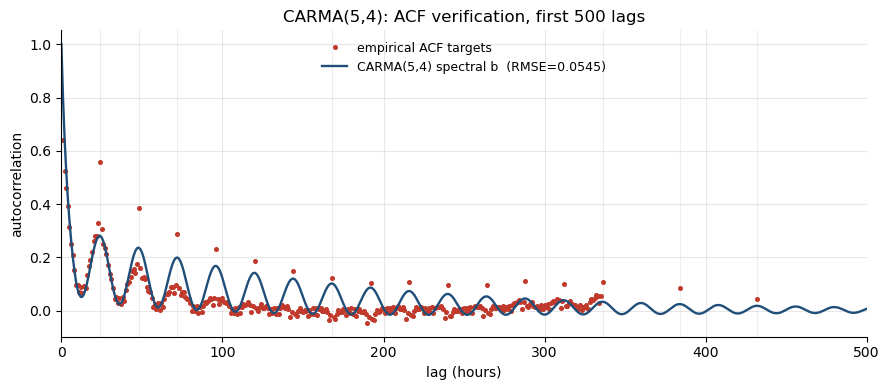

saved: solar_multiscale_carma_selected.json
saved: solar_carma_b_init.json
saved: solar_multiscale_carma_selected_components.csv

=== Init for nb03: p=5, q=4 ===
  b = [1.833802e-05, 2.714271e-03, 7.034044e-02, 7.572329e-02, 1.000000e+00]


In [6]:
# Spectral factorisation CARMA(5,4) + save
kap_r = kap_b[:Kr]
sh_r = sh_b[:Kr]
kap_c = kap_b[Kr:]
sh_c = sh_b[Kr:]
om_c = om_c_fixed.copy()
p = Kr + 2 * Kc

roots_ar = [complex(-kap_r[i], 0.0) for i in range(Kr)]
for j in range(Kc):
    roots_ar.extend([
        complex(-kap_c[j], om_c[j]),
        complex(-kap_c[j], -om_c[j]),
    ])
ar = np.real(np.poly(roots_ar)[1:])

A = np.zeros((p, p))
for i in range(p - 1):
    A[i, i + 1] = 1.0
A[-1, :] = -ar[::-1]
ep = np.zeros(p)
ep[-1] = 1.0
P_norm = solve_continuous_lyapunov(A, -np.outer(ep, ep))

fp_r2 = lambda k: np.array([1.0, k ** 2])
fp_c2 = lambda k, o: np.array([1.0, 2 * (k ** 2 - o ** 2), (k ** 2 + o ** 2) ** 2])
fr2 = [fp_r2(k) for k in kap_r]
fc2 = [fp_c2(k, o) for k, o in zip(kap_c, om_c)]

P_u = np.zeros(p)
for i in range(Kr):
    t = np.array([2 * kap_r[i] * sh_r[i] * v0])
    for i2 in range(Kr):
        if i2 != i:
            t = np.polymul(t, fr2[i2])
    for j in range(Kc):
        t = np.polymul(t, fc2[j])
    P_u = np.polyadd(P_u, t)

for j in range(Kc):
    t = np.polymul(
        np.array([2 * kap_c[j] * sh_c[j] * v0]),
        np.array([1.0, kap_c[j] ** 2 + om_c[j] ** 2]),
    )
    for i in range(Kr):
        t = np.polymul(t, fr2[i])
    for j2 in range(Kc):
        if j2 != j:
            t = np.polymul(t, fc2[j2])
    P_u = np.polyadd(P_u, t)

print(f"P(u) degree={len(P_u) - 1}  leading={P_u[0]:.4e}  "
      f"(expected 2v0*sum(kappa*w)={2 * v0 * float(np.r_[kap_r, kap_c] @ sh_b):.4e})")

u_roots = np.roots(P_u)
b_roots = np.array([
    1j * np.sqrt(uk) if np.real(1j * np.sqrt(uk)) < np.real(-1j * np.sqrt(uk))
    else -1j * np.sqrt(uk)
    for uk in u_roots
])
print(f"All b roots Re<0: {np.all(np.real(b_roots) < 0)}  |  max Re={np.max(np.real(b_roots)):.2e}")

b_vec_raw = np.real(np.poly(b_roots)[::-1])
b_vec = b_vec_raw / b_vec_raw[-1]   # book convention: monic highest MA coefficient b_q = 1
Pb = P_norm @ b_vec
var0 = float(b_vec @ Pb)
print(f"b = {np.array2string(b_vec, precision=6, separator=', ')}")
print(f"b^T*P_norm*b = {var0:.4e}  (v0={v0:.4e})")

eAh = np.stack([expm(A * float(h)) for h in lags])
rho_sf = (eAh @ Pb) @ b_vec / var0
rmse_sf = float(np.sqrt(np.mean((rho_sf - rho_emp) ** 2)))
wssr_sf = float(np.sum((sw * (rho_sf - rho_emp)) ** 2))
print("\n=== ACF verification ===")
print(f"  Multiscale model  RMSE={rmse_24:.6f}  WSSR={wssr_24:.4f}")
print(f"  Spectral b        RMSE={rmse_sf:.6f}  WSSR={wssr_sf:.4f}")
print(f"  delta RMSE = {rmse_sf - rmse_24:.2e}  (should be near 0)")

diag = [1, 2, 3, 6, 12, 18, 24, 30, 48, 72, 96, 120, 144, 168, 240, 336]
eAhd = np.stack([expm(A * float(h)) for h in diag])
cmp = pd.DataFrame({
    "lag_h": diag,
    "empirical": [acf(k) for k in diag],
    "multiscale": rho_24(best.x, np.array(diag, dtype=float)),
    f"CARMA({p},{p-1}) sf-b": (eAhd @ Pb) @ b_vec / var0,
})
cmp["err_sf"] = cmp[f"CARMA({p},{p-1}) sf-b"] - cmp["empirical"]
display(cmp.style.format({c: "{:.4f}" for c in cmp.columns[1:]}).hide(axis="index"))

plot_mask = lags_fit <= ACF_PLOT_MAX_LAG_H
kk = np.arange(0, ACF_PLOT_MAX_LAG_H + 1)
eAhp = np.stack([expm(A * float(h)) for h in kk])
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(lags_fit[plot_mask], rho_emp[plot_mask], "o", ms=2.6, color="#c0392b", label="empirical ACF targets")
ax.plot(kk, (eAhp @ Pb) @ b_vec / var0, "-", lw=1.7, color="#1f4e79",
        label=f"CARMA({p},{p-1}) spectral b  (RMSE={rmse_sf:.4f})")
for d in [24, 48, 72, 168, 336, 384, 432]:
    if d <= ACF_PLOT_MAX_LAG_H:
        ax.axvline(d, color="#eee", lw=0.8, zorder=0)
ax.set_xlim(0, ACF_PLOT_MAX_LAG_H)
ax.set_xlabel("lag (hours)")
ax.set_ylabel("autocorrelation")
ax.set_title(f"CARMA({p},{p-1}): ACF verification, first 500 lags")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

def _ser(x):
    x = float(x)
    return None if not np.isfinite(x) else x

components = [
    {
        "component": str(r["component"]),
        "kind": str(r["kind"]),
        "half_life_h": float(r["half_life_h"]),
        "half_life_d": float(r["half_life_d"]),
        "period_h": _ser(r["period_h"]),
        "share": float(r["share"]),
    }
    for _, r in summary_24.iterrows()
]

half_life_bounds_h = {
    str(label): {
        "lower": float(HALF_LIFE_BOUNDS_H.loc[label, "lower_h"]),
        "upper": float(HALF_LIFE_BOUNDS_H.loc[label, "upper_h"]),
    }
    for label in component_labels
}
half_life_bounds_d = {
    str(label): {
        "lower": float(HALF_LIFE_BOUNDS_H.loc[label, "lower_h"] / 24.0),
        "upper": float(HALF_LIFE_BOUNDS_H.loc[label, "upper_h"] / 24.0),
    }
    for label in component_labels
}

payload = dict(
    selected=dict(Kr=Kr, Kc=Kc, order=p),
    roots=[[float(r.real), float(r.imag)] for r in roots_ar],
    ar_coefficients=[float(x) for x in ar],
    b_coefficients=[float(x) for x in b_vec],
    metrics=dict(
        rmse_multiscale=float(rmse_24),
        wssr_multiscale=float(wssr_24),
        rmse_spectral=float(rmse_sf),
        wssr_spectral=float(wssr_sf),
    ),
    components=components,
    calibration=dict(
        max_fit_lag_h=int(lags_fit.max()),
        max_fit_lag_d=float(lags_fit.max() / 24.0),
        dense_lag_max_h=int(short_lags.max()),
        dense_lag_max_d=float(short_lags.max() / 24.0),
        long_anchor_lags_h=[int(x) for x in long_anchor_lags],
        half_life_bounds_h=half_life_bounds_h,
        half_life_bounds_d=half_life_bounds_d,
        acf_plot_max_lag_h=int(ACF_PLOT_MAX_LAG_H),
        n_fit_lags=int(len(lags_fit)),
    ),
    note="Solar XtQ. Kr=3 Kc=1 period=24h fixed; all half-lives are optimised inside explicit manual bounds. CARMA(5,4). Monic b[-1]=1 (book convention).",
)
(OUT / "solar_multiscale_carma_selected.json").write_text(json.dumps(payload, indent=2))
(OUT / "solar_carma_b_init.json").write_text(json.dumps(dict(
    b_coefficients=[float(x) for x in b_vec],
    AR_order=int(p),
    MA_order=int(p - 1),
    acf_rmse_spectral=float(rmse_sf),
    acf_rmse_multiscale=float(rmse_24),
    note=f"CARMA({p},{p-1}) spectral b from ACF calibration with free half-lives and manual bounds. Monic b[-1]=1 (book convention).",
), indent=2))

summary_24.to_csv(OUT / "solar_multiscale_carma_selected_components.csv", index=False)
print("saved: solar_multiscale_carma_selected.json")
print("saved: solar_carma_b_init.json")
print("saved: solar_multiscale_carma_selected_components.csv")
print(f"\n=== Init for nb03: p={p}, q={p - 1} ===")
print(f"  b = {np.array2string(b_vec, precision=6, separator=', ')}")


## ACF calibration excluding daily-grid lags

This diagnostic reruns the same multiscale ACF calibration but removes lags on the
24h grid from the least-squares objective. The excluded lags remain visible in the
plot, so the daily spikes can be inspected without forcing the CARMA initialisation
to match them. This section only estimates the multiscale parameters; it does not
perform spectral factorisation and does not overwrite the JSON initialisation files.


Candidate ACF lags before exclusion: 350
ACF lags used after daily exclusion: 322
Excluded daily-grid lags: 28
  first excluded lags h: [24, 48, 72, 96, 120, 144, 168, 192, 216, 240, 264, 288, 312, 336, 384, 432, 504, 600, 720, 960]
Note: strict daily exclusion removes the original long anchors because they are exact multiples of 24h.
      Set USE_OFFGRID_LONG_ANCHORS=True to keep shifted long-horizon anchors in this diagnostic.


component,kind,half_life_h,half_life_d,period_h,share,at_lower,at_upper
real_fast,real,2.00,0.08,inf,0.814,True,False
real_mid,real,65.35,2.72,inf,0.145,False,False
real_slow,real,168.01,7.00,inf,0.000,False,False
osc_daily,osc,140.62,5.86,24.0,0.041,False,False


RMSE on used fit lags = 0.035507  WSSR = 1.2426
RMSE on first 500 lags: all=0.041200, used=0.035507, excluded_daily=0.140869
Optimizer status: 2 `ftol` termination condition is satisfied.
Comparison with baseline calibration:


component,half_life_h_no_daily,half_life_d_no_daily,share_no_daily,half_life_h_baseline,half_life_d_baseline,share_baseline
real_fast,2.00,0.08,0.814,2.00,0.08,0.665
real_mid,65.35,2.72,0.145,79.63,3.32,0.194
real_slow,168.01,7.00,0.000,168.00,7.00,0.000
osc_daily,140.62,5.86,0.041,130.06,5.42,0.141


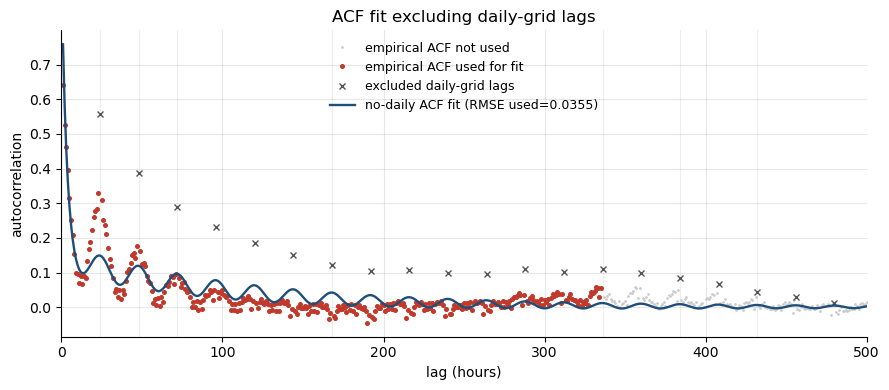

In [4]:
# ACF diagnostic fit: ignore exact multiples of 24h, no spectral factorisation
Kr_no_daily, Kc_no_daily = 3, 1
m_no_daily = Kr_no_daily + Kc_no_daily
n_hl_no_daily = Kr_no_daily + Kc_no_daily
component_labels_no_daily = np.array(["real_fast", "real_mid", "real_slow", "osc_daily"])
om_c_fixed_no_daily = np.array([2 * np.pi / 24.0])

ACF_PLOT_MAX_LAG_NO_DAILY_H = 500
DAILY_PERIOD_H = 24
DAILY_EXCLUSION_WINDOW_H = 0  # 0 excludes exact multiples only; 1 excludes 23/24/25, etc.

# Strict mode keeps the same candidate lags and then removes daily-grid lags.
# Set this to True if you want long-horizon anchors shifted off the 24h grid.
USE_OFFGRID_LONG_ANCHORS = False
OFFGRID_LONG_ANCHOR_OFFSET_H = 12

if "HALF_LIFE_BOUNDS_H" in globals():
    HALF_LIFE_BOUNDS_NO_DAILY_H = HALF_LIFE_BOUNDS_H.copy()
else:
    HALF_LIFE_BOUNDS_NO_DAILY_H = pd.DataFrame({
        "component": component_labels_no_daily,
        "lower_h": [0.3, 2.0, 24.0, 12.0],
        "upper_h": [72.0, 60.0 * 24.0, 365.0 * 24.0, 180.0 * 24.0],
    }).set_index("component")

hl_lower_no_daily_h = HALF_LIFE_BOUNDS_NO_DAILY_H.loc[component_labels_no_daily, "lower_h"].to_numpy(float)
hl_upper_no_daily_h = HALF_LIFE_BOUNDS_NO_DAILY_H.loc[component_labels_no_daily, "upper_h"].to_numpy(float)
if np.any(hl_lower_no_daily_h <= 0.0) or np.any(hl_upper_no_daily_h <= hl_lower_no_daily_h):
    raise ValueError("Half-life bounds must satisfy 0 < lower_h < upper_h for every component.")

short_lags_no_daily = np.arange(1, 337)
if "long_anchor_lags" in globals():
    base_long_anchor_lags_no_daily = np.array(long_anchor_lags, dtype=int)
else:
    base_long_anchor_lags_no_daily = np.array([
        384, 432, 504, 600, 720, 960, 1200, 1440,
        1800, 2160, 2520, 2880, 3600, 4320,
    ], dtype=int)

long_anchor_lags_no_daily = base_long_anchor_lags_no_daily.copy()
if USE_OFFGRID_LONG_ANCHORS:
    long_anchor_lags_no_daily = long_anchor_lags_no_daily + int(OFFGRID_LONG_ANCHOR_OFFSET_H)

candidate_lags_no_daily = np.unique(np.r_[short_lags_no_daily, long_anchor_lags_no_daily]).astype(int)

def distance_to_daily_grid(k, period_h=DAILY_PERIOD_H):
    r = np.mod(np.asarray(k, dtype=int), int(period_h))
    return np.minimum(r, int(period_h) - r)

daily_distance_no_daily = distance_to_daily_grid(candidate_lags_no_daily)
keep_no_daily = daily_distance_no_daily > DAILY_EXCLUSION_WINDOW_H
lags_fit_no_daily = candidate_lags_no_daily[keep_no_daily]
lags_excluded_no_daily = candidate_lags_no_daily[~keep_no_daily]

rho_emp_fit_no_daily = np.array([acf(k) for k in lags_fit_no_daily])

wts_fit_no_daily = 1.0 / np.sqrt(lags_fit_no_daily.astype(float))
wts_fit_no_daily[lags_fit_no_daily <= 72] *= 2.0
wts_fit_no_daily[lags_fit_no_daily >= 168] *= 2.0
wts_fit_no_daily[lags_fit_no_daily >= 720] *= 1.5
wts_fit_no_daily[lags_fit_no_daily >= 2160] *= 2.0

for anchor in [1, 6, 12, 18, 24, 30, 48, 72, 96, 120, 144, 168, 336]:
    wts_fit_no_daily[lags_fit_no_daily == anchor] *= 8.0

for anchor in [720, 1440, 2160, 2880, 3600, 4320]:
    wts_fit_no_daily[lags_fit_no_daily == anchor] *= 10.0

sw_fit_no_daily = np.sqrt(wts_fit_no_daily / wts_fit_no_daily.mean())

def unpack_theta_no_daily(theta):
    theta = np.asarray(theta, dtype=float)
    hl_all = np.exp(theta[:n_hl_no_daily])
    hl_real = hl_all[:Kr_no_daily]
    hl_osc = hl_all[Kr_no_daily:Kr_no_daily + Kc_no_daily]
    kap_real = np.log(2.0) / hl_real
    kap_osc = np.log(2.0) / hl_osc
    sh = softmax(theta[n_hl_no_daily:n_hl_no_daily + m_no_daily])
    return hl_real, hl_osc, kap_real, kap_osc, sh

def rho_24_no_daily(theta, k):
    hl_real, hl_osc, kap_real, kap_osc, sh = unpack_theta_no_daily(theta)
    h = np.asarray(k, dtype=float)
    out = np.zeros_like(h, dtype=float)
    for i in range(Kr_no_daily):
        out += sh[i] * np.exp(-kap_real[i] * h)
    for j in range(Kc_no_daily):
        idx = Kr_no_daily + j
        out += sh[idx] * np.exp(-kap_osc[j] * h) * np.cos(om_c_fixed_no_daily[j] * h)
    return out

lb_no_daily = np.r_[np.log(hl_lower_no_daily_h), [-9.0] * m_no_daily]
ub_no_daily = np.r_[np.log(hl_upper_no_daily_h), [9.0] * m_no_daily]

start_hl_no_daily = np.array([
    [2.0, 24.0, 30.0 * 24.0, 72.0],
    [4.0, 36.0, 60.0 * 24.0, 96.0],
    [1.0, 12.0, 120.0 * 24.0, 48.0],
    [6.0, 48.0, 180.0 * 24.0, 120.0],
    [3.0, 30.0, 240.0 * 24.0, 96.0],
    [8.0, 72.0, 365.0 * 24.0, 96.0],
    [10.0, 120.0, 90.0 * 24.0, 168.0],
], dtype=float)
start_hl_no_daily = np.clip(start_hl_no_daily, hl_lower_no_daily_h, hl_upper_no_daily_h)

print(f"Candidate ACF lags before exclusion: {len(candidate_lags_no_daily)}")
print(f"ACF lags used after daily exclusion: {len(lags_fit_no_daily)}")
print(f"Excluded daily-grid lags: {len(lags_excluded_no_daily)}")
print(f"  first excluded lags h: {lags_excluded_no_daily[:20].tolist()}")
if not np.any(lags_fit_no_daily > short_lags_no_daily.max()):
    print("Note: strict daily exclusion removes the original long anchors because they are exact multiples of 24h.")
    print("      Set USE_OFFGRID_LONG_ANCHORS=True to keep shifted long-horizon anchors in this diagnostic.")

rng_no_daily = np.random.default_rng(123)
best_no_daily = None
n_starts_no_daily = 80

for s in range(n_starts_no_daily):
    if s < len(start_hl_no_daily):
        xs = np.r_[np.log(start_hl_no_daily[s]), [0.0] * m_no_daily]
    else:
        xs = np.r_[np.log(start_hl_no_daily[s % len(start_hl_no_daily)]), [0.0] * m_no_daily]
        xs[:n_hl_no_daily] += rng_no_daily.normal(0, 0.65, n_hl_no_daily)
        xs[n_hl_no_daily:n_hl_no_daily + m_no_daily] += rng_no_daily.normal(0, 1.2, m_no_daily)

    xs = np.clip(xs, lb_no_daily, ub_no_daily)

    r = least_squares(
        lambda t: sw_fit_no_daily * (rho_24_no_daily(t, lags_fit_no_daily) - rho_emp_fit_no_daily),
        xs,
        bounds=(lb_no_daily, ub_no_daily),
        max_nfev=9000,
    )
    if best_no_daily is None or r.cost < best_no_daily.cost:
        best_no_daily = r

hl_real_no_daily, hl_osc_no_daily, kap_real_no_daily, kap_osc_no_daily, sh_no_daily = unpack_theta_no_daily(best_no_daily.x)
hl_best_no_daily = np.r_[hl_real_no_daily, hl_osc_no_daily]

rows_no_daily = []
for i in range(Kr_no_daily):
    rows_no_daily.append({
        "component": component_labels_no_daily[i],
        "kind": "real",
        "half_life_h": hl_real_no_daily[i],
        "half_life_d": hl_real_no_daily[i] / 24.0,
        "period_h": np.inf,
        "share": sh_no_daily[i],
    })
for j in range(Kc_no_daily):
    idx = Kr_no_daily + j
    rows_no_daily.append({
        "component": component_labels_no_daily[idx],
        "kind": "osc",
        "half_life_h": hl_osc_no_daily[j],
        "half_life_d": hl_osc_no_daily[j] / 24.0,
        "period_h": 24.0,
        "share": sh_no_daily[idx],
    })

summary_no_daily = pd.DataFrame(rows_no_daily)
summary_no_daily["at_lower"] = np.isclose(hl_best_no_daily, hl_lower_no_daily_h, rtol=1e-5, atol=1e-6)
summary_no_daily["at_upper"] = np.isclose(hl_best_no_daily, hl_upper_no_daily_h, rtol=1e-5, atol=1e-6)

display(summary_no_daily.style.format({
    "half_life_h": "{:.2f}",
    "half_life_d": "{:.2f}",
    "period_h": "{:.1f}",
    "share": "{:.3f}",
}).hide(axis="index"))

rho_fit_model_no_daily = rho_24_no_daily(best_no_daily.x, lags_fit_no_daily)
rmse_fit_no_daily = float(np.sqrt(np.mean((rho_fit_model_no_daily - rho_emp_fit_no_daily) ** 2)))
wssr_fit_no_daily = float(np.sum((sw_fit_no_daily * (rho_fit_model_no_daily - rho_emp_fit_no_daily)) ** 2))

plot_lags_no_daily = np.arange(1, ACF_PLOT_MAX_LAG_NO_DAILY_H + 1)
rho_emp_plot_no_daily = np.array([acf(k) for k in plot_lags_no_daily])
rho_model_plot_no_daily = rho_24_no_daily(best_no_daily.x, plot_lags_no_daily)
plot_daily_mask_no_daily = distance_to_daily_grid(plot_lags_no_daily) <= DAILY_EXCLUSION_WINDOW_H
plot_target_mask_no_daily = np.isin(plot_lags_no_daily, lags_fit_no_daily)

rmse_plot_all_no_daily = float(np.sqrt(np.mean((rho_model_plot_no_daily - rho_emp_plot_no_daily) ** 2)))
rmse_plot_used_no_daily = float(np.sqrt(np.mean((rho_model_plot_no_daily[plot_target_mask_no_daily] - rho_emp_plot_no_daily[plot_target_mask_no_daily]) ** 2)))
rmse_plot_excluded_no_daily = float(np.sqrt(np.mean((rho_model_plot_no_daily[plot_daily_mask_no_daily] - rho_emp_plot_no_daily[plot_daily_mask_no_daily]) ** 2)))

print(f"RMSE on used fit lags = {rmse_fit_no_daily:.6f}  WSSR = {wssr_fit_no_daily:.4f}")
print(f"RMSE on first {ACF_PLOT_MAX_LAG_NO_DAILY_H} lags: all={rmse_plot_all_no_daily:.6f}, used={rmse_plot_used_no_daily:.6f}, excluded_daily={rmse_plot_excluded_no_daily:.6f}")
print("Optimizer status:", best_no_daily.status, best_no_daily.message)

if "summary_24" in globals() and "component" in summary_24.columns:
    compare_no_daily = summary_no_daily[["component", "half_life_h", "half_life_d", "share"]].merge(
        summary_24[["component", "half_life_h", "half_life_d", "share"]],
        on="component",
        suffixes=("_no_daily", "_baseline"),
    )
    print("Comparison with baseline calibration:")
    display(compare_no_daily.style.format({
        "half_life_h_no_daily": "{:.2f}",
        "half_life_d_no_daily": "{:.2f}",
        "share_no_daily": "{:.3f}",
        "half_life_h_baseline": "{:.2f}",
        "half_life_d_baseline": "{:.2f}",
        "share_baseline": "{:.3f}",
    }).hide(axis="index"))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(plot_lags_no_daily, rho_emp_plot_no_daily, ".", ms=2.0, color="#cccccc", label="empirical ACF not used")
ax.plot(plot_lags_no_daily[plot_target_mask_no_daily], rho_emp_plot_no_daily[plot_target_mask_no_daily],
        "o", ms=2.6, color="#c0392b", label="empirical ACF used for fit")
ax.plot(plot_lags_no_daily[plot_daily_mask_no_daily], rho_emp_plot_no_daily[plot_daily_mask_no_daily],
        "x", ms=4.0, color="#555555", label="excluded daily-grid lags")
ax.plot(plot_lags_no_daily, rho_model_plot_no_daily, "-", lw=1.7, color="#1f4e79",
        label=f"no-daily ACF fit (RMSE used={rmse_fit_no_daily:.4f})")
for d in [24, 48, 72, 168, 336, 384, 432]:
    if d <= ACF_PLOT_MAX_LAG_NO_DAILY_H:
        ax.axvline(d, color="#eee", lw=0.8, zorder=0)
ax.set_xlim(0, ACF_PLOT_MAX_LAG_NO_DAILY_H)
ax.set_xlabel("lag (hours)")
ax.set_ylabel("autocorrelation")
ax.set_title("ACF fit excluding daily-grid lags")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()
